# Visualización de Keypoints — LSA Dataset
Solo necesita `data/dataset/toy_dataset.json`. No requiere videos ni MediaPipe.

**Estructura del vector 1086:**
- `[0:66]` Pose — 33 puntos × 2 (x,y)
- `[66:1002]` Cara — 468 puntos × 2 (x,y)
- `[1002:1044]` Mano izq — 21 puntos × 2 (x,y)
- `[1044:1086]` Mano der — 21 puntos × 2 (x,y)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

DATASET_PATH = Path('../data/dataset/toy_dataset.json')
with open(DATASET_PATH) as f:
    dataset = json.load(f)

print(f'Clips cargados: {len(dataset)}')
for e in dataset[:5]:
    print(f"  {e['source'][:50]:50s}  {e['n_frames']} frames")

Clips cargados: 29
  DSC_0797 Plan Salud Ciudad si                       572 frames
  DSC_0798 Incluir Salud que es si                    545 frames
  DSC_0799 Incluir Salud tramite si                   777 frames
  DSC_0802 Pasaje gratis si                           747 frames
  DSC_0809 Peaje libre si                             503 frames


In [2]:
# Conexiones del esqueleto de pose (índices MediaPipe)
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),     # cara
    (0,4),(4,5),(5,6),(6,8),
    (9,10),                       # hombros
    (11,12),(11,13),(13,15),      # brazo izq
    (12,14),(14,16),              # brazo der
    (11,23),(12,24),(23,24),      # torso
    (23,25),(25,27),(24,26),(26,28),  # piernas
]

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),      # pulgar
    (0,5),(5,6),(6,7),(7,8),      # índice
    (0,9),(9,10),(10,11),(11,12), # medio
    (0,13),(13,14),(14,15),(15,16),# anular
    (0,17),(17,18),(18,19),(19,20),# meñique
    (5,9),(9,13),(13,17),         # palma
]

def unpack(vector):
    v = np.array(vector, dtype=np.float32)
    pose  = v[0:66].reshape(33, 2)
    face  = v[66:1002].reshape(468, 2)
    lhand = v[1002:1044].reshape(21, 2)
    rhand = v[1044:1086].reshape(21, 2)
    return pose, face, lhand, rhand

def draw_frame(ax, vector, title=''):
    pose, face, lhand, rhand = unpack(vector)
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1); ax.set_ylim(1, 0)
    ax.set_aspect('equal'); ax.axis('off')
    if title:
        ax.set_title(title, color='white', fontsize=9, pad=4)

    # Cara (puntos pequeños, azul)
    mask_face = ~(np.all(face == 0, axis=1))
    ax.scatter(face[mask_face, 0], face[mask_face, 1],
               s=1, c='#4fc3f7', alpha=0.4, zorder=2)

    # Esqueleto de pose
    mask_pose = ~(np.all(pose == 0, axis=1))
    for a, b in POSE_CONNECTIONS:
        if mask_pose[a] and mask_pose[b]:
            ax.plot([pose[a,0], pose[b,0]], [pose[a,1], pose[b,1]],
                    c='#81c784', lw=1.5, alpha=0.8, zorder=3)
    ax.scatter(pose[mask_pose, 0], pose[mask_pose, 1],
               s=18, c='#a5d6a7', zorder=4)

    # Mano izquierda (naranja)
    mask_lh = ~(np.all(lhand == 0, axis=1))
    if mask_lh.any():
        for a, b in HAND_CONNECTIONS:
            if mask_lh[a] and mask_lh[b]:
                ax.plot([lhand[a,0], lhand[b,0]], [lhand[a,1], lhand[b,1]],
                        c='#ffb74d', lw=1.5, zorder=5)
        ax.scatter(lhand[mask_lh, 0], lhand[mask_lh, 1],
                   s=14, c='#ffe0b2', zorder=6)

    # Mano derecha (rosa)
    mask_rh = ~(np.all(rhand == 0, axis=1))
    if mask_rh.any():
        for a, b in HAND_CONNECTIONS:
            if mask_rh[a] and mask_rh[b]:
                ax.plot([rhand[a,0], rhand[b,0]], [rhand[a,1], rhand[b,1]],
                        c='#f48fb1', lw=1.5, zorder=5)
        ax.scatter(rhand[mask_rh, 0], rhand[mask_rh, 1],
                   s=14, c='#fce4ec', zorder=6)

print('Funciones de visualización cargadas.')

Funciones de visualización cargadas.


## 1 — Slider frame a frame
Seleccioná el clip y navegá frame por frame.

In [ ]:
clip_names = [e['source'] for e in dataset]

clip_dd = widgets.Dropdown(options=clip_names, description='Clip:', layout=widgets.Layout(width='70%'))
frame_sl = widgets.IntSlider(min=0, max=1, step=1, description='Frame:', layout=widgets.Layout(width='70%'))
out = widgets.Output()

def on_clip_change(change):
    entry = next(e for e in dataset if e['source'] == clip_dd.value)
    frame_sl.max = entry['n_frames'] - 1
    frame_sl.value = 0
    render()

def render(*args):
    entry = next(e for e in dataset if e['source'] == clip_dd.value)
    vector = entry['keypoints'][frame_sl.value]
    m = entry['metadata']
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 7))
        fig.patch.set_facecolor('#1a1a2e')
        title = f"Frame {frame_sl.value}/{entry['n_frames']-1}  |  conf: {m['confidence_avg']:.2f}"
        draw_frame(ax, vector, title)
        legend = [
            mpatches.Patch(color='#a5d6a7', label='Pose'),
            mpatches.Patch(color='#4fc3f7', label='Cara'),
            mpatches.Patch(color='#ffb74d', label='Mano izq'),
            mpatches.Patch(color='#f48fb1', label='Mano der'),
        ]
        ax.legend(handles=legend, loc='lower right', fontsize=7,
                  facecolor='#1a1a2e', labelcolor='white', framealpha=0.6)
        plt.tight_layout()
        plt.show()

clip_dd.observe(on_clip_change, names='value')
frame_sl.observe(render, names='value')
on_clip_change(None)

display(clip_dd, frame_sl, out)

Dropdown(description='Clip:', layout=Layout(width='70%'), options=('DSC_0797 Plan Salud Ciudad si', 'DSC_0798 …

IntSlider(value=0, description='Frame:', layout=Layout(width='70%'), max=571)

Output()

## 2 — Grilla de frames
Vista general de la evolución del clip a lo largo del tiempo.

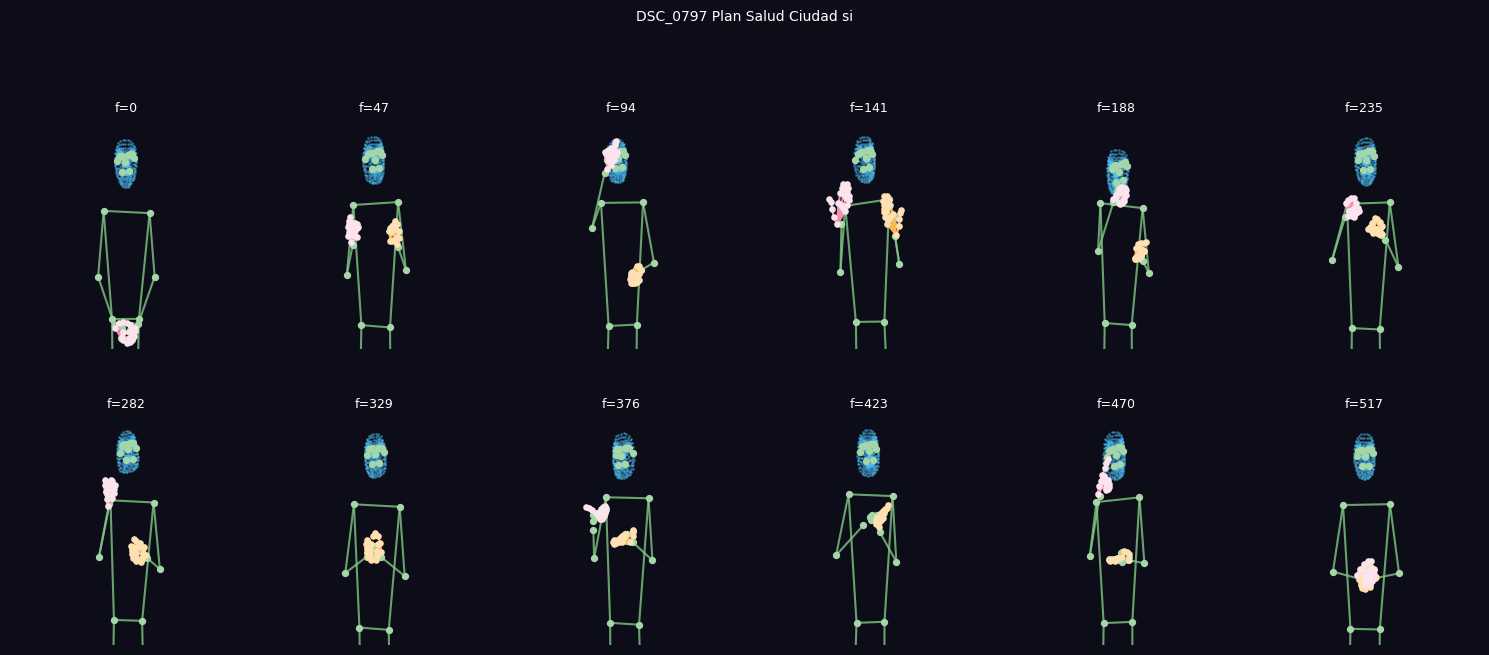

In [4]:
CLIP_IDX = 0   # ← cambiá este número para ver otro clip
N_COLS   = 6
N_FRAMES = 12  # cuántos frames mostrar en la grilla

entry = dataset[CLIP_IDX]
kps   = entry['keypoints']
step  = max(1, len(kps) // N_FRAMES)
idxs  = list(range(0, len(kps), step))[:N_FRAMES]

n_rows = (len(idxs) + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 2.5, n_rows * 3.5))
fig.patch.set_facecolor('#0d0d1a')
axes = axes.flatten()

for i, fi in enumerate(idxs):
    draw_frame(axes[i], kps[fi], title=f'f={fi}')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(entry['source'][:60], color='white', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Calidad de detección a lo largo del tiempo
Confianza + presencia de manos frame a frame.

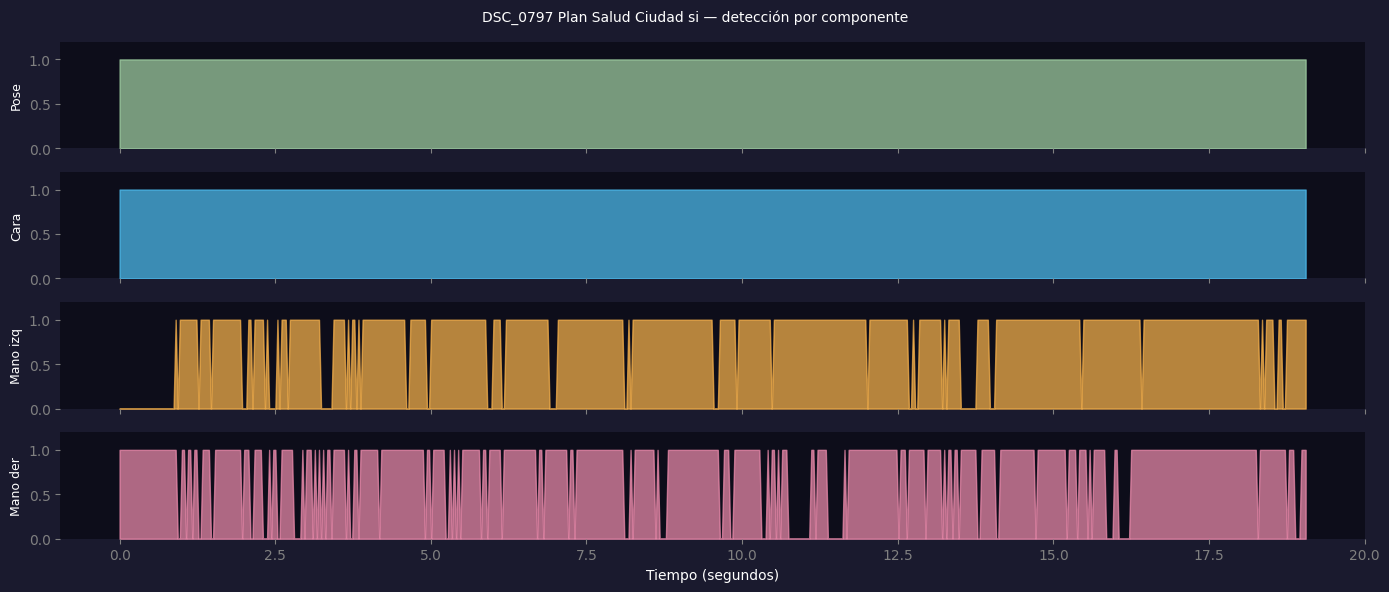

pose: 100%  cara: 100%  mano izq: 83%  mano der: 80%  conf avg: 0.76


In [5]:
entry = dataset[CLIP_IDX]
kps   = entry['keypoints']
fps   = entry['metadata'].get('fps', 30)

frames_n = list(range(len(kps)))
seconds  = [f / fps for f in frames_n]

# Detectar presencia por componente (zeros → no detectado)
def detected(v, start, end):
    return float(not np.all(np.array(v[start:end]) == 0))

pose_det  = [detected(v, 0,    66)   for v in kps]
face_det  = [detected(v, 66,   1002) for v in kps]
lhand_det = [detected(v, 1002, 1044) for v in kps]
rhand_det = [detected(v, 1044, 1086) for v in kps]

fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
fig.patch.set_facecolor('#1a1a2e')

specs = [
    (pose_det,  '#a5d6a7', 'Pose'),
    (face_det,  '#4fc3f7', 'Cara'),
    (lhand_det, '#ffb74d', 'Mano izq'),
    (rhand_det, '#f48fb1', 'Mano der'),
]
for ax, (data, color, label) in zip(axes, specs):
    ax.fill_between(seconds, data, alpha=0.7, color=color)
    ax.set_ylabel(label, color='white', fontsize=9)
    ax.set_ylim(0, 1.2)
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='gray')
    ax.spines[:].set_visible(False)

axes[-1].set_xlabel('Tiempo (segundos)', color='white')
fig.suptitle(f"{entry['source'][:60]} — detección por componente", color='white', fontsize=10)
plt.tight_layout()
plt.show()

m = entry['metadata']
print(f"pose: {m['pose_pct']:.0%}  cara: {m['face_pct']:.0%}  "
      f"mano izq: {m['left_hand_pct']:.0%}  mano der: {m['right_hand_pct']:.0%}  "
      f"conf avg: {m['confidence_avg']:.2f}")